# Задание №3 Моделирование экспоненциально и нормально распределенных СВ


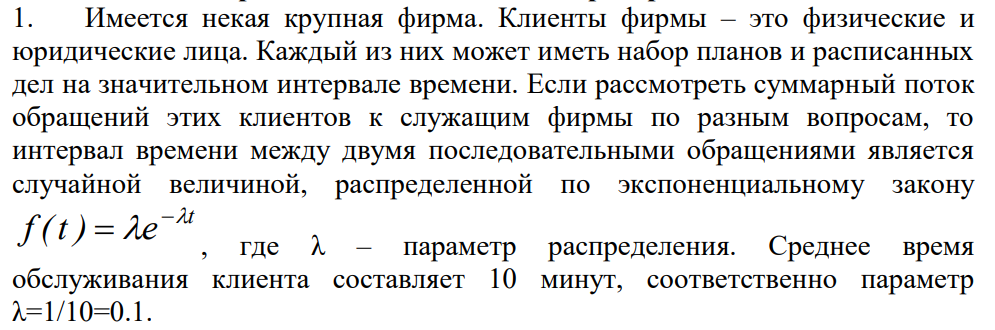

## Моделирование экспоненциально распределенных случайных величин

### 1. Моделирование методом обратной функции
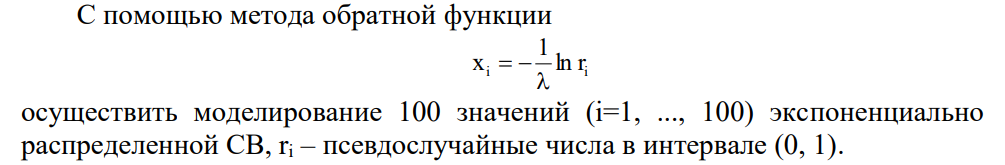

### 2. Статистическая обработка результатов
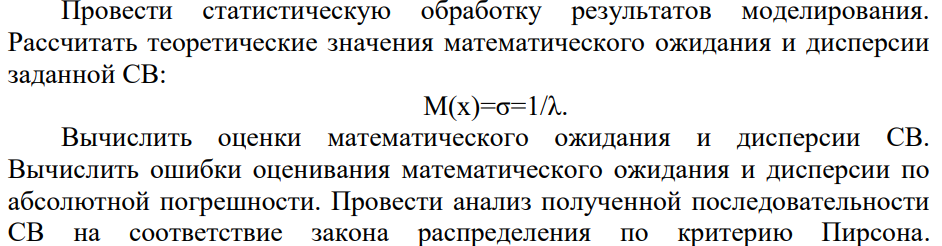

In [14]:
import numpy as np
import math

np.random.seed(42)

# Параметры
lam = 0.1  # λ = 1/10
n = 100

# Теоретические значения
M_theory = 1 / lam      # = 10
D_theory = 1 / lam**2    # = 100

print(f"Теоретичесцкое M(x) = {M_theory}")
print(f"Теоретическая D(x) = {D_theory}")

Теоретичесцкое M(x) = 10.0
Теоретическая D(x) = 99.99999999999999


In [15]:
# Генерация псевдослучайных чисел r_i из U(0,1)
r = np.random.uniform(0, 1, n)

# Метод обратной функции: x_i = -1/λ * ln(r_i)
x = -1 / lam * np.log(r)

print("Первые 10 значений выборки:")
print(np.round(x[:10], 4))

# Оценки математического ожидания и дисперсии
M_est   = np.mean(x)
D_est   = np.var(x, ddof=1) # несмещённая оценка

# Абсолютные погрешности
delta_M = abs(M_est - M_theory)
delta_D = abs(D_est - D_theory)

print(f"Теория M = {M_theory:.4f}")
print(f"Теория D = {D_theory:.4f}")
print(f"Выборочное среднее M = {M_est:.4f}")
print(f"Выборочная дисперсия D = {D_est:.4f}")
print(f"Погрешность M: ΔM = {delta_M:.4f}")
print(f"Погрешность D: ΔD = {delta_D:.4f}")

Первые 10 значений выборки:
[ 9.8206  0.5054  3.1198  5.1306 18.5778 18.5793 28.4587  1.4367  5.0897
  3.4521]
Теория M = 10.0000
Теория D = 100.0000
Выборочное среднее M = 10.9660
Выборочная дисперсия D = 103.0354
Погрешность M: ΔM = 0.9660
Погрешность D: ΔD = 3.0354


### 3. Разбивка выборки на интервалы
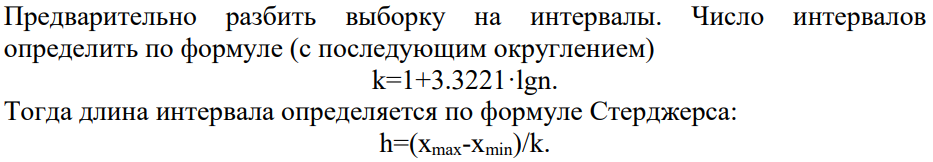

In [16]:
# Число интервалов по формуле Стёрджерса
k = int(round(1 + 3.3221 * np.log10(n)))
x_min, x_max = x.min(), x.max()
h = (x_max - x_min) / k

# Границы интервалов
bins = np.array([x.min() + i * h for i in range(k + 1)])
bins[-1] = x.max() + 1e-9  # включаем правую границу

# Частоты и середины
counts = np.array([np.sum((x >= bins[i]) & (x < bins[i+1])) for i in range(k)])
midpoints = (bins[:-1] + bins[1:]) / 2

print(f"k = {k},  h = {h:.4f}")
print(f"x_min = {x_min:.4f}, x_max = {x_max:.4f}\n")
print(f"{'Интервал':>22} | {'Середина':>9} | {'ni':>4}")
print("-" * 43)
for i in range(k):
    print(f"[{bins[i]:8.4f}, {bins[i+1]:8.4f}) | {midpoints[i]:9.4f} | {counts[i]:4}")

k = 8,  h = 6.4822
x_min = 0.1320, x_max = 51.9899

              Интервал |  Середина |   ni
-------------------------------------------
[  0.1320,   6.6142) |    3.3731 |   46
[  6.6142,  13.0965) |    9.8554 |   24
[ 13.0965,  19.5787) |   16.3376 |   11
[ 19.5787,  26.0610) |   22.8198 |   10
[ 26.0610,  32.5432) |   29.3021 |    5
[ 32.5432,  39.0255) |   35.7843 |    3
[ 39.0255,  45.5077) |   42.2666 |    0
[ 45.5077,  51.9899) |   48.7488 |    1


### 4. Проверка гипотезы по критерию Пирсона
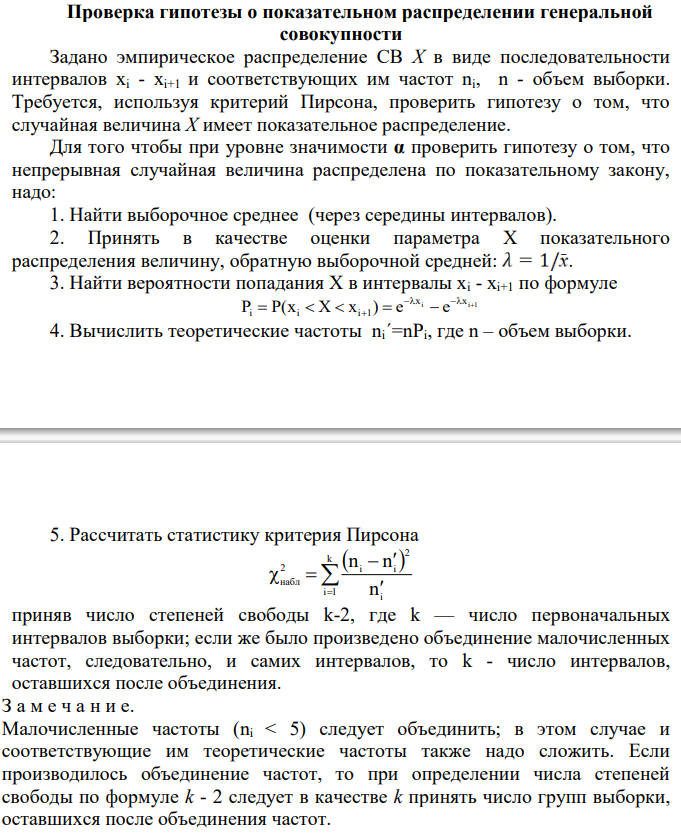

In [17]:
from scipy import stats

# Выборочное среднее через середины интервалов
x_bar = np.sum(midpoints * counts) / n
lam_est = 1 / x_bar

print(f"Выборочное среднее (через середины): x̄ = {x_bar:.4f}")
print(f"Оценка параметра: λ̂ = {lam_est:.4f}\n")

# Вероятности Pi = e^(-λ*xi) - e^(-λ*xi+1)
P = np.exp(-lam_est * bins[:-1]) - np.exp(-lam_est * bins[1:])
n_theor = n * P

# Объединение малочисленных интервалов (ni < 5)
merged_ni, merged_ni_theor = [], []
buf_ni, buf_nt = 0, 0.0
for ni_i, nt_i in zip(counts, n_theor):
    buf_ni += ni_i
    buf_nt += nt_i
    if buf_ni >= 5:
        merged_ni.append(buf_ni)
        merged_ni_theor.append(buf_nt)
        buf_ni, buf_nt = 0, 0.0
if buf_ni > 0:
    merged_ni[-1] += buf_ni
    merged_ni_theor[-1] += buf_nt

merged_ni = np.array(merged_ni)
merged_ni_theor = np.array(merged_ni_theor)
k_merged = len(merged_ni)

header = "ni'"
print(f"{'ni':>6} | {header:>8}")
print("-" * 18)
for a, b in zip(merged_ni, merged_ni_theor):
    print(f"{a:6} | {b:8.4f}")

# Статистика критерия Пирсона
chi2_obs = np.sum((merged_ni - merged_ni_theor)**2 / merged_ni_theor)

df = k_merged - 2
alpha = 0.05
chi2_crit = stats.chi2.ppf(1 - alpha, df)

print(f"\nk после объединения = {k_merged},  степени свободы = {df}")
print(f"χ²_набл = {chi2_obs:.4f}")
print(f"χ²_кр   = {chi2_crit:.4f}  (α={alpha})")
print()
if chi2_obs < chi2_crit:
    print("χ²_набл < χ²_кр → нет оснований отвергнуть гипотезу об экспоненциальном распределении")
else:
    print("χ²_набл > χ²_кр → гипотеза отвергается")

Выборочное среднее (через середины): x̄ = 11.0222
Оценка параметра: λ̂ = 0.0907

    ni |      ni'
------------------
    46 |  43.9331
    24 |  24.3994
    11 |  13.5508
    10 |   7.5258
     9 |   8.5061

k после объединения = 5,  степени свободы = 3
χ²_набл = 1.4260
χ²_кр   = 7.8147  (α=0.05)

χ²_набл < χ²_кр → нет оснований отвергнуть гипотезу об экспоненциальном распределении


## Моделирование нормально распределенных случайных величин

### 1. Метод центральной предельной теоремы (ЦПТ)
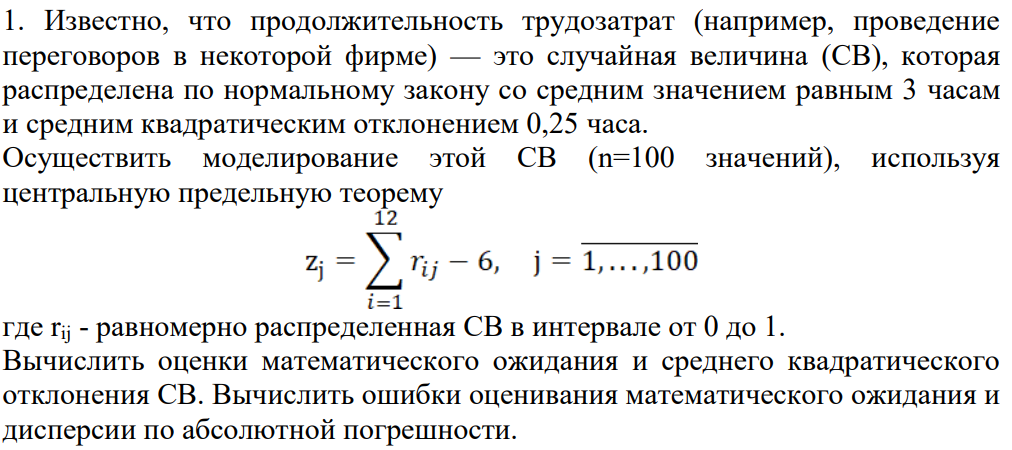

In [18]:
import numpy as np
import math
from scipy import stats

# Параметры нормального распределения
m = 3         # математическое ожидание (часы)
sigma = 0.25  # СКО
n = 100

M_theory_norm = m
D_theory_norm = sigma**2

print(f"Теоретическое M(x) = {M_theory_norm}")
print(f"Теоретическая D(x) = {D_theory_norm}")

Теоретическое M(x) = 3
Теоретическая D(x) = 0.0625


In [19]:
# Метод ЦПТ: z_j = Σ r_ij (i=1..12) - 6
R_clt = np.random.uniform(0, 1, (n, 12))

# z_j = sum(r_ij, i=1..12) - 6
z_clt = R_clt.sum(axis=1) - 6   # стандартная нормальная СВ

# Масштабирование: x = m + σ·z
x_clt = m + sigma * z_clt

# Оценки
M_clt = np.mean(x_clt)
D_clt = np.var(x_clt, ddof=1)
sigma_clt = np.sqrt(D_clt)

delta_M_clt = abs(M_clt - M_theory_norm)
delta_D_clt = abs(D_clt - D_theory_norm)

print(f"ЦПТ: M = {M_clt:.4f}, σ = {sigma_clt:.4f}")
print(f"Погрешность M: {delta_M_clt:.4f}, погрешность D: {delta_D_clt:.6f}")

ЦПТ: M = 2.9955, σ = 0.2609
Погрешность M: 0.0045, погрешность D: 0.005566


### 2. Метод Мюллера
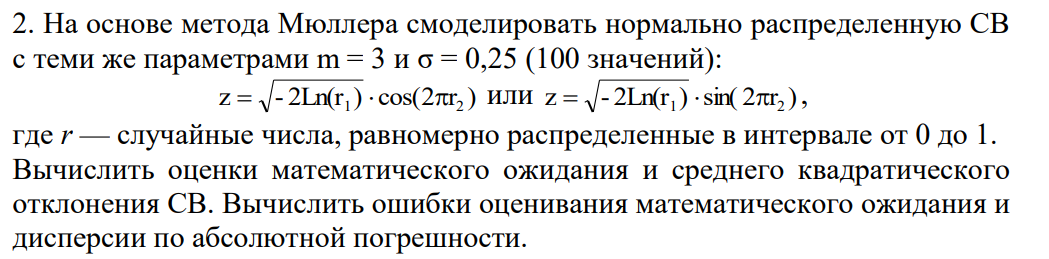

In [20]:
r1 = np.random.uniform(0, 1, n)
r2 = np.random.uniform(0, 1, n)

z_mueller = np.sqrt(-2 * np.log(r1)) * np.cos(2 * np.pi * r2)

# Масштабирование
x_mueller = m + sigma * z_mueller

# Выборочные оценки
M_mueller = np.mean(x_mueller)
D_mueller = np.var(x_mueller, ddof=1)
sigma_mueller = np.sqrt(D_mueller)

delta_M_mueller = abs(M_mueller - M_theory_norm)
delta_D_mueller = abs(D_mueller - D_theory_norm)

print(f"Мюллер: M = {M_mueller:.4f}, σ = {sigma_mueller:.4f}")
print(f"Погрешность M: {delta_M_mueller:.4f}, погрешность D: {delta_D_mueller:.6f}")

Мюллер: M = 3.0072, σ = 0.2313
Погрешность M: 0.0072, погрешность D: 0.008979


### 3. Проверка гипотезы по критерию Пирсона
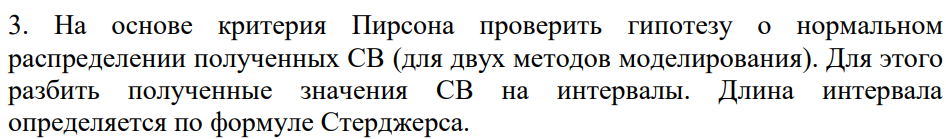

A)</br>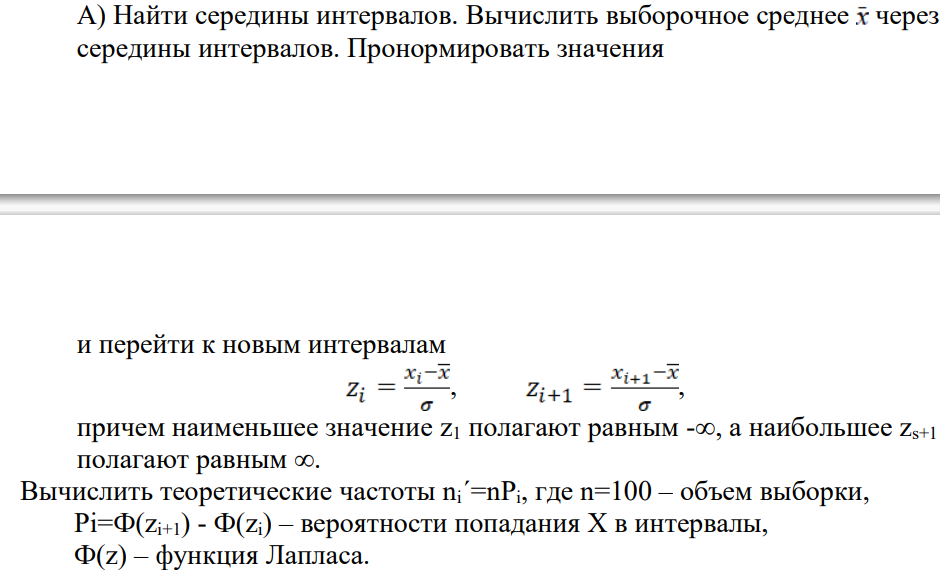

In [21]:
def build_intervals_normal(x_data, label):
    """Разбивка на интервалы, вычисление x̄, σ̂ и нормированных границ z_i."""
    n_loc = len(x_data)
    k = round(1 + 3.3221 * math.log10(n_loc))
    h = (x_data.max() - x_data.min()) / k

    bins = np.array([x_data.min() + i * h for i in range(k + 1)])
    bins[-1] = x_data.max() + 1e-9

    counts   = np.array([np.sum((x_data >= bins[i]) & (x_data < bins[i+1])) for i in range(k)])
    midpoints = (bins[:-1] + bins[1:]) / 2

    # Выборочное среднее через середины интервалов
    x_bar     = np.sum(midpoints * counts) / n_loc
    sigma_est = np.sqrt(np.sum(counts * (midpoints - x_bar)**2) / (n_loc - 1))

    # Нормированные границы: z_i = (x_i - x̄) / σ̂
    z_bounds = (bins - x_bar) / sigma_est
    z_bounds[0]  = -np.inf
    z_bounds[-1] =  np.inf

    print(f"=== {label} ===")
    print(f"k = {k},  h = {h:.4f},  x̄ = {x_bar:.4f},  σ̂ = {sigma_est:.4f}\n")
    print(f"{'Интервал':>26} | {'ni':>4} | {'zi':>8} | {'zi+1':>8}")
    print("-" * 57)
    for i in range(k):
        zlo = "-∞"           if np.isinf(z_bounds[i])   else f"{z_bounds[i]:.4f}"
        zhi = "+∞"           if np.isinf(z_bounds[i+1]) else f"{z_bounds[i+1]:.4f}"
        print(f"[{bins[i]:10.4f}, {bins[i+1]:10.4f}) | {counts[i]:4} | {zlo:>8} | {zhi:>8}")

    return bins, counts, midpoints, z_bounds, x_bar, sigma_est

bins_clt, counts_clt, mid_clt, zb_clt, xbar_clt, sig_clt_p = build_intervals_normal(x_clt,    "ЦПТ")
print()
bins_mul, counts_mul, mid_mul, zb_mul, xbar_mul, sig_mul_p = build_intervals_normal(x_mueller, "Мюллер")

=== ЦПТ ===
k = 8,  h = 0.1540,  x̄ = 3.0003,  σ̂ = 0.2624

                  Интервал |   ni |       zi |     zi+1
---------------------------------------------------------
[    2.4211,     2.5752) |    4 |       -∞ |  -1.6203
[    2.5752,     2.7292) |   14 |  -1.6203 |  -1.0333
[    2.7292,     2.8833) |   13 |  -1.0333 |  -0.4462
[    2.8833,     3.0373) |   26 |  -0.4462 |   0.1409
[    3.0373,     3.1913) |   22 |   0.1409 |   0.7280
[    3.1913,     3.3454) |   10 |   0.7280 |   1.3151
[    3.3454,     3.4994) |    7 |   1.3151 |   1.9021
[    3.4994,     3.6534) |    4 |   1.9021 |       +∞

=== Мюллер ===
k = 8,  h = 0.1408,  x̄ = 3.0075,  σ̂ = 0.2380

                  Интервал |   ni |       zi |     zi+1
---------------------------------------------------------
[    2.4654,     2.6062) |    5 |       -∞ |  -1.6864
[    2.6062,     2.7470) |    8 |  -1.6864 |  -1.0947
[    2.7470,     2.8878) |   21 |  -1.0947 |  -0.5030
[    2.8878,     3.0287) |   17 |  -0.5030 |   0.0888


Б)</br>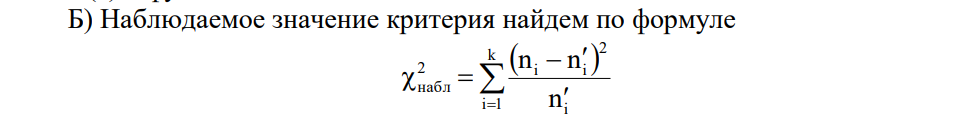

In [22]:
def pearson_chi2(counts_loc, z_bounds, n_loc, label):
    """Вычисляет χ²_набл, объединяя интервалы с ni < 5."""
    # Pi = Φ(z_{i+1}) - Φ(z_i)  через scipy norm.cdf
    P       = np.array([stats.norm.cdf(z_bounds[i+1]) - stats.norm.cdf(z_bounds[i])
                        for i in range(len(counts_loc))])
    n_theor = n_loc * P

    # Объединение малочисленных интервалов (ni < 5)
    merged_ni, merged_nt = [], []
    buf_ni, buf_nt = 0, 0.0
    for ni_i, nt_i in zip(counts_loc, n_theor):
        buf_ni += ni_i; buf_nt += nt_i
        if buf_ni >= 5:
            merged_ni.append(buf_ni); merged_nt.append(buf_nt)
            buf_ni, buf_nt = 0, 0.0
    if buf_ni > 0:
        merged_ni[-1] += buf_ni; merged_nt[-1] += buf_nt

    # Если последняя группа всё ещё малочисленная — слить с предыдущей
    if len(merged_ni) > 1 and merged_ni[-1] < 5:
        last_ni = merged_ni.pop()
        last_nt = merged_nt.pop()
        merged_ni[-1] += last_ni
        merged_nt[-1] += last_nt

    merged_ni = np.array(merged_ni)
    merged_nt = np.array(merged_nt)

    chi2_obs = np.sum((merged_ni - merged_nt)**2 / merged_nt)

    print(f"=== {label}: χ²_набл ===")
    print(f"{'ni':>6} | {'ni_теор':>9} | {'(ni-ni_)²/ni_':>14}")
    print("-" * 36)
    for a, b in zip(merged_ni, merged_nt):
        print(f"{a:6} | {b:9.4f} | {(a-b)**2/b:14.4f}")
    print(f"\nχ²_набл = {chi2_obs:.4f}   (k после объединения = {len(merged_ni)})")
    return chi2_obs, len(merged_ni)

chi2_clt, k_clt = pearson_chi2(counts_clt, zb_clt, n, "ЦПТ")
print()
chi2_mul, k_mul = pearson_chi2(counts_mul, zb_mul, n, "Мюллер")

=== ЦПТ: χ²_набл ===
    ni |   ni_теор |  (ni-ni_)²/ni_
------------------------------------
    18 |   15.0742 |         0.5679
    13 |   17.6992 |         1.2477
    26 |   22.8291 |         0.4404
    22 |   21.0661 |         0.0414
    10 |   13.9068 |         1.0975
    11 |    9.4246 |         0.2633

χ²_набл = 3.6582   (k после объединения = 6)

=== Мюллер: χ²_набл ===
    ni |   ni_теор |  (ni-ni_)²/ni_
------------------------------------
     5 |    4.5859 |         0.0374
     8 |    9.0969 |         0.1323
    21 |   17.0668 |         0.9065
    17 |   22.7867 |         1.4696
    24 |   21.6536 |         0.2543
    16 |   14.6450 |         0.1254
     9 |   10.1651 |         0.1335

χ²_набл = 3.0588   (k после объединения = 7)


В)</br>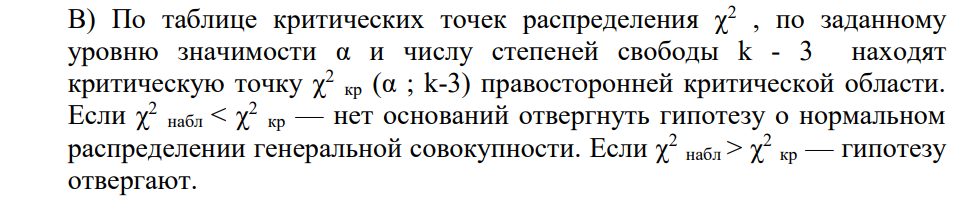

In [23]:
alpha = 0.05

def pearson_conclusion(chi2_obs, k_merged, label):
    df = k_merged - 3   # степени свободы = k - 3 для нормального распределения
    chi2_crit = stats.chi2.ppf(1 - alpha, df)
    print(f"=== {label} ===")
    print(f"k после объединения = {k_merged},  степени свободы = {df}")
    print(f"χ²_набл = {chi2_obs:.4f}")
    print(f"χ²_кр   = {chi2_crit:.4f}  (α = {alpha})")
    if chi2_obs < chi2_crit:
        print("χ²_набл < χ²_кр  →  нет оснований отвергнуть гипотезу о нормальном распределении\n")
    else:
        print("χ²_набл > χ²_кр  →  гипотеза о нормальном распределении отвергается\n")

pearson_conclusion(chi2_clt, k_clt, "ЦПТ")
pearson_conclusion(chi2_mul, k_mul, "Мюллер")

=== ЦПТ ===
k после объединения = 6,  степени свободы = 3
χ²_набл = 3.6582
χ²_кр   = 7.8147  (α = 0.05)
χ²_набл < χ²_кр  →  нет оснований отвергнуть гипотезу о нормальном распределении

=== Мюллер ===
k после объединения = 7,  степени свободы = 4
χ²_набл = 3.0588
χ²_кр   = 9.4877  (α = 0.05)
χ²_набл < χ²_кр  →  нет оснований отвергнуть гипотезу о нормальном распределении



### 4. Проверка гипотезы по критерию Колмогорова-Смирнова
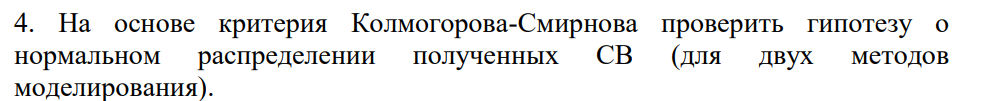

A)
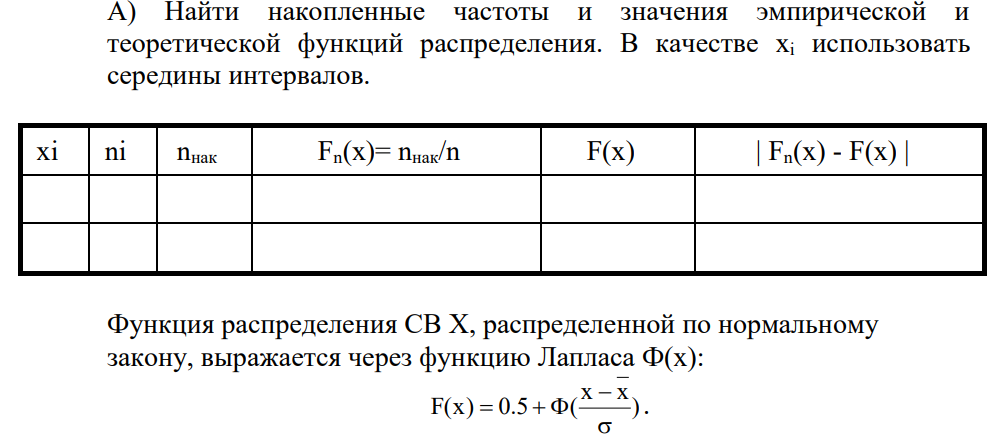

In [24]:
def ks_table(x_data, midpoints, counts, n_loc, label):
    """Таблица: xi | ni | n_нак | Fn(x) | F(x) | |Fn-F|"""
    n_cum  = np.cumsum(counts)
    Fn     = n_cum / n_loc
    # x̄ и σ̂из сырых данных
    x_bar  = np.mean(x_data)
    sigma  = np.std(x_data, ddof=1)
    # F(x) = 0.5 + Φ((x - x̄)/σ̂)
    F      = stats.norm.cdf(midpoints, loc=x_bar, scale=sigma)
    diff   = np.abs(Fn - F)

    print(f"=== {label}: таблица Колмогорова–Смирнова ===")
    print(f"{'xi':>9} | {'ni':>4} | {'n_нак':>6} | {'Fn(x)':>7} | {'F(x)':>7} | {'|Fn-F|':>7}")
    print("-" * 57)
    for xi, ni, nc, fn, fx, d in zip(midpoints, counts, n_cum, Fn, F, diff):
        print(f"{xi:9.4f} | {ni:4} | {nc:6} | {fn:7.4f} | {fx:7.4f} | {d:7.4f}")

    return diff

diff_clt = ks_table(x_clt,     mid_clt, counts_clt, n, "ЦПТ")
print()
diff_mul = ks_table(x_mueller, mid_mul, counts_mul, n, "Мюллер")

=== ЦПТ: таблица Колмогорова–Смирнова ===
       xi |   ni |  n_нак |   Fn(x) |    F(x) |  |Fn-F|
---------------------------------------------------------
   2.4982 |    4 |      4 |  0.0400 |  0.0283 |  0.0117
   2.6522 |   14 |     18 |  0.1800 |  0.0941 |  0.0859
   2.8062 |   13 |     31 |  0.3100 |  0.2341 |  0.0759
   2.9603 |   26 |     57 |  0.5700 |  0.4463 |  0.1237
   3.1143 |   22 |     79 |  0.7900 |  0.6756 |  0.1144
   3.2683 |   10 |     89 |  0.8900 |  0.8522 |  0.0378
   3.4224 |    7 |     96 |  0.9600 |  0.9491 |  0.0109
   3.5764 |    4 |    100 |  1.0000 |  0.9870 |  0.0130

=== Мюллер: таблица Колмогорова–Смирнова ===
       xi |   ni |  n_нак |   Fn(x) |    F(x) |  |Fn-F|
---------------------------------------------------------
   2.5358 |    5 |      5 |  0.0500 |  0.0208 |  0.0292
   2.6766 |    8 |     13 |  0.1300 |  0.0765 |  0.0535
   2.8174 |   21 |     34 |  0.3400 |  0.2061 |  0.1339
   2.9583 |   17 |     51 |  0.5100 |  0.4163 |  0.0937
   3.0991 | 

Б)</br>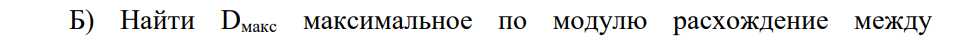
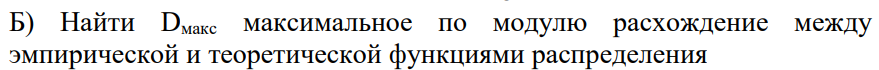

In [25]:
D_clt = diff_clt.max()
D_mul = diff_mul.max()

print(f"D_макс (ЦПТ)    = {D_clt:.4f}")
print(f"D_макс (Мюллер) = {D_mul:.4f}")

D_макс (ЦПТ)    = 0.1237
D_макс (Мюллер) = 0.1339


В)</br>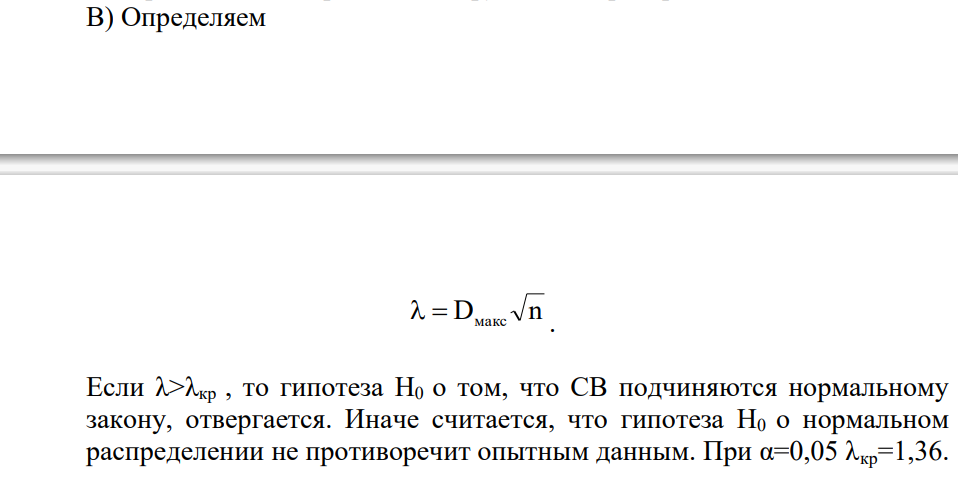

In [26]:
lam_crit = 1.36   # критическое значение при α = 0.05

lam_clt = D_clt * math.sqrt(n)
lam_mul = D_mul * math.sqrt(n)

print(f"{'Метод':<10} | {'D_макс':>8} | {'λ = D·√n':>9} | {'λ_кр':>6} | Вывод")
print("-" * 65)
for label, D_val, lam_val in [("ЦПТ", D_clt, lam_clt), ("Мюллер", D_mul, lam_mul)]:
    verdict = "Н₀ не отвергается" if lam_val < lam_crit else "Н₀ отвергается"
    print(f"{label:<10} | {D_val:>8.4f} | {lam_val:>9.4f} | {lam_crit:>6.2f} | {verdict}")

Метод      |   D_макс |  λ = D·√n |   λ_кр | Вывод
-----------------------------------------------------------------
ЦПТ        |   0.1237 |    1.2371 |   1.36 | Н₀ не отвергается
Мюллер     |   0.1339 |    1.3390 |   1.36 | Н₀ не отвергается
